# Extension 2: Non-linear Reward Matching Bandit

This notebook implements the second extension required by Seminar_paper_2: a non-linear reward setting for combinatorial semi-bandits.

We extend the matching semi-bandit from a purely linear reward to a non-linear objective containing edge rewards, diversity bonus, and pairwise interaction terms. The learner still uses UCB estimates for unknown edge rewards, but the oracle maximizes a non-linear UCB objective. We compare this method against a linear CombUCB1 baseline that ignores the non-linear terms. Our experiments report cumulative regret, scaling with the number of ground items, scaling with inverse gap, sensitivity to the non-linear strength, ablation of reward components, and oracle runtime. 

In [1]:
"""
Extension 2: Non-linear reward extension for CombUCB1-style combinatorial semi-bandits.

This file implements a synthetic many-to-one student-college matching bandit with
non-linear rewards. It compares:
  1) Linear CombUCB1 baseline: Hungarian oracle on edge UCBs only.
  2) Nonlinear UCB oracle: exact small-instance nonlinear oracle using UCB edge estimates plus
     a known nonlinear diversity / quadratic objective.

Run:
    python extension2_nonlinear_bandit.py

Dependencies: numpy, scipy, matplotlib
"""

from __future__ import annotations

from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

Edge = Tuple[int, int]  # (student, college)


@dataclass
class NonlinearMatchingConfig:
    n_students: int = 5
    n_colleges: int = 4
    capacities: Tuple[int, ...] = (5, 5, 5, 5)
    horizon: int = 800
    diversity_lambda: float = 1.20
    interaction_gamma: float = 0.80
    seed: int = 0

In [2]:
class NonlinearCollegeMatchingProblem:
    """
    Many-to-one matching with stochastic edge rewards and non-linear matching-level reward.

    True one-step reward of a matching M is:
        F(M) = sum_{(s,c) in M} mu[s,c]
               + lambda * diversity(M)
               + gamma * pairwise_interaction(M)

    The agent observes semi-bandit feedback: sampled edge rewards for the chosen edges.
    The nonlinear diversity/interaction part is assumed known and deterministic.
    """

    def __init__(self, cfg: NonlinearMatchingConfig):
        assert len(cfg.capacities) == cfg.n_colleges
        assert sum(cfg.capacities) >= cfg.n_students, "Need enough slots for all students."
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self.n_students = cfg.n_students
        self.n_colleges = cfg.n_colleges
        self.capacities = np.asarray(cfg.capacities, dtype=int)

        # Synthetic expected edge rewards in [0.05, 0.95].
        # A structured matrix makes learning non-trivial but reproducible.
        base = self.rng.uniform(0.15, 0.85, size=(self.n_students, self.n_colleges))
        preferred = np.arange(self.n_students) % self.n_colleges
        for s, c in enumerate(preferred):
            base[s, c] = min(0.95, base[s, c] + 0.25)
        self.true_means = np.clip(base, 0.05, 0.95)

        # College categories for diversity. Example: 0/1 are category A, 2/3 category B.
        self.college_category = np.arange(self.n_colleges) % 2

        # Symmetric known pairwise interaction between colleges.
        # Positive for complementary categories, slightly negative for same category.
        self.pair_bonus = np.zeros((self.n_colleges, self.n_colleges))
        for i in range(self.n_colleges):
            for j in range(i + 1, self.n_colleges):
                self.pair_bonus[i, j] = 1.0 if self.college_category[i] != self.college_category[j] else -0.35
                self.pair_bonus[j, i] = self.pair_bonus[i, j]

    def sample_edge_reward(self, s: int, c: int) -> float:
        return float(self.rng.binomial(1, self.true_means[s, c]))

    def check_feasible(self, matching: Sequence[Edge]) -> bool:
        students = [s for s, _ in matching]
        if len(students) != len(set(students)):
            return False
        usage = np.zeros(self.n_colleges, dtype=int)
        for _, c in matching:
            usage[c] += 1
        return bool(np.all(usage <= self.capacities) and len(matching) == self.n_students)

    def diversity_bonus(self, matching: Sequence[Edge]) -> float:
        """Concave coverage over categories: submodular-style diversity."""
        category_counts: Dict[int, int] = {}
        for _, c in matching:
            cat = int(self.college_category[c])
            category_counts[cat] = category_counts.get(cat, 0) + 1
        return sum(np.sqrt(v) for v in category_counts.values())

    def quadratic_bonus(self, matching: Sequence[Edge]) -> float:
        """Pairwise college interaction term."""
        val = 0.0
        colleges = [c for _, c in matching]
        for c1, c2 in combinations(colleges, 2):
            val += self.pair_bonus[c1, c2]
        return val / max(1, len(colleges))

    def nonlinear_value(self, matching: Sequence[Edge], edge_weight_matrix: np.ndarray) -> float:
        linear = sum(edge_weight_matrix[s, c] for s, c in matching)
        return float(
            linear
            + self.cfg.diversity_lambda * self.diversity_bonus(matching)
            + self.cfg.interaction_gamma * self.quadratic_bonus(matching)
        )

    def true_value(self, matching: Sequence[Edge]) -> float:
        return self.nonlinear_value(matching, self.true_means)

In [3]:
class VirtualSlotTransformer:
    """Converts many-to-one matching into one-to-one matching by virtual college slots."""

    def __init__(self, problem: NonlinearCollegeMatchingProblem):
        self.problem = problem
        self.virtual_to_college: Dict[int, int] = {}
        slot = 0
        for c, cap in enumerate(problem.capacities):
            for _ in range(int(cap)):
                self.virtual_to_college[slot] = c
                slot += 1
        self.n_virtual = slot

    def expand(self, real_matrix: np.ndarray) -> np.ndarray:
        out = np.zeros((self.problem.n_students, self.n_virtual))
        for s in range(self.problem.n_students):
            for v, c in self.virtual_to_college.items():
                out[s, v] = real_matrix[s, c]
        return out

    def virtual_to_real_matching(self, virtual_matching: Sequence[Tuple[int, int]]) -> List[Edge]:
        return [(s, self.virtual_to_college[v]) for s, v in virtual_matching]

In [4]:
class ExactSmallOracle:
    """Exhaustive oracle for small synthetic instances; used only for evaluation."""

    def __init__(self, problem: NonlinearCollegeMatchingProblem):
        self.problem = problem
        self.all_matchings = self._enumerate_feasible_matchings()

    def _enumerate_feasible_matchings(self) -> List[List[Edge]]:
        n, m = self.problem.n_students, self.problem.n_colleges
        capacities = self.problem.capacities
        out: List[List[Edge]] = []

        def backtrack(s: int, usage: np.ndarray, cur: List[Edge]) -> None:
            if s == n:
                out.append(cur.copy())
                return
            for c in range(m):
                if usage[c] < capacities[c]:
                    usage[c] += 1
                    cur.append((s, c))
                    backtrack(s + 1, usage, cur)
                    cur.pop()
                    usage[c] -= 1

        backtrack(0, np.zeros(m, dtype=int), [])
        return out

    def argmax_nonlinear(self, weight_matrix: np.ndarray) -> Tuple[List[Edge], float]:
        best_m, best_v = None, -np.inf
        for matching in self.all_matchings:
            v = self.problem.nonlinear_value(matching, weight_matrix)
            if v > best_v:
                best_m, best_v = matching, v
        return list(best_m), float(best_v)

In [5]:
class LinearCombUCB1Baseline:
    """Baseline: ignores nonlinear terms when choosing actions; uses Hungarian on edge UCBs."""

    def __init__(self, problem: NonlinearCollegeMatchingProblem):
        self.problem = problem
        self.transformer = VirtualSlotTransformer(problem)
        self.counts = np.zeros((problem.n_students, problem.n_colleges))
        self.reward_sum = np.zeros_like(self.counts)
        self._initialize_each_edge_once()

    def _initialize_each_edge_once(self) -> None:
        for s in range(self.problem.n_students):
            for c in range(self.problem.n_colleges):
                self.counts[s, c] = 1
                self.reward_sum[s, c] = self.problem.sample_edge_reward(s, c)

    def select(self, t: int) -> List[Edge]:
        mean = self.reward_sum / self.counts
        bonus = np.sqrt(1.5 * np.log(t + 1) / self.counts)
        real_ucb = mean + bonus
        virtual_ucb = self.transformer.expand(real_ucb)
        rows, cols = linear_sum_assignment(-virtual_ucb)
        return self.transformer.virtual_to_real_matching(list(zip(rows, cols)))

    def update(self, matching: Sequence[Edge]) -> None:
        for s, c in matching:
            r = self.problem.sample_edge_reward(s, c)
            self.counts[s, c] += 1
            self.reward_sum[s, c] += r

In [6]:
class NonlinearUCBOracle:
    """
    Extension 2 algorithm: UCB estimates + nonlinear oracle.

    For the small synthetic experiment we can use an exact exhaustive nonlinear oracle.
    In a larger report, this exact oracle can be replaced by greedy/local-search.
    """

    def __init__(self, problem: NonlinearCollegeMatchingProblem):
        self.problem = problem
        self.exact_oracle = ExactSmallOracle(problem)
        self.counts = np.zeros((problem.n_students, problem.n_colleges))
        self.reward_sum = np.zeros_like(self.counts)
        self._initialize_each_edge_once()

    def _initialize_each_edge_once(self) -> None:
        for s in range(self.problem.n_students):
            for c in range(self.problem.n_colleges):
                self.counts[s, c] = 1
                self.reward_sum[s, c] = self.problem.sample_edge_reward(s, c)

    def select(self, t: int) -> List[Edge]:
        mean = self.reward_sum / self.counts
        bonus = np.sqrt(1.5 * np.log(t + 1) / self.counts)
        ucb = mean + bonus
        matching, _ = self.exact_oracle.argmax_nonlinear(ucb)
        return matching

    def update(self, matching: Sequence[Edge]) -> None:
        for s, c in matching:
            r = self.problem.sample_edge_reward(s, c)
            self.counts[s, c] += 1
            self.reward_sum[s, c] += r


def run_algorithm(problem: NonlinearCollegeMatchingProblem, algo, horizon: int) -> np.ndarray:
    exact = ExactSmallOracle(problem)
    opt_matching, opt_value = exact.argmax_nonlinear(problem.true_means)
    regrets = []
    for t in range(1, horizon + 1):
        matching = algo.select(t)
        assert problem.check_feasible(matching)
        step_value = problem.true_value(matching)
        regrets.append(opt_value - step_value)
        algo.update(matching)
    return np.cumsum(regrets)

Final cumulative regret
  Linear CombUCB1 baseline: 246.57 ± 77.66
  Nonlinear UCB oracle:      137.02 ± 20.78


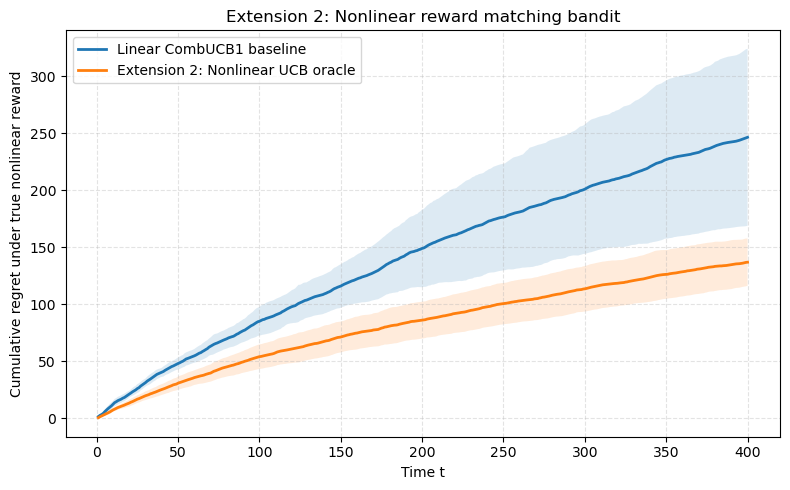

In [7]:
def experiment(num_runs: int = 10, horizon: int = 400) -> None:
    linear_curves, nonlinear_curves = [], []
    for seed in range(num_runs):
        cfg = NonlinearMatchingConfig(horizon=horizon, seed=seed)

        # Use separate but identical environments so the algorithms do not share RNG state.
        p1 = NonlinearCollegeMatchingProblem(cfg)
        p2 = NonlinearCollegeMatchingProblem(cfg)

        linear_curves.append(run_algorithm(p1, LinearCombUCB1Baseline(p1), horizon))
        nonlinear_curves.append(run_algorithm(p2, NonlinearUCBOracle(p2), horizon))

    linear = np.vstack(linear_curves)
    nonlinear = np.vstack(nonlinear_curves)

    print("Final cumulative regret")
    print(f"  Linear CombUCB1 baseline: {linear[:, -1].mean():.2f} ± {linear[:, -1].std():.2f}")
    print(f"  Nonlinear UCB oracle:      {nonlinear[:, -1].mean():.2f} ± {nonlinear[:, -1].std():.2f}")

    x = np.arange(1, horizon + 1)
    plt.figure(figsize=(8, 5))
    for curves, label in [(linear, "Linear CombUCB1 baseline"), (nonlinear, "Extension 2: Nonlinear UCB oracle")]:
        mean = curves.mean(axis=0)
        std = curves.std(axis=0)
        plt.plot(x, mean, label=label, linewidth=2)
        plt.fill_between(x, mean - std, mean + std, alpha=0.15)
    plt.xlabel("Time t")
    plt.ylabel("Cumulative regret under true nonlinear reward")
    plt.title("Extension 2: Nonlinear reward matching bandit")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.savefig("extension2_nonlinear_regret.png", dpi=200)
    plt.show()


if __name__ == "__main__":
    experiment(num_runs=10, horizon=400)

# Additional Experiments for Extension 2

The core implementation above already defines:

- `NonlinearCollegeMatchingProblem`
- `LinearCombUCB1Baseline`
- `NonlinearUCBOracle`
- `run_algorithm`

The following cells add the missing experiments needed for a more complete Extension 2 evaluation:

1. gap sensitivity;
2. diversity-strength sensitivity;
3. ablation study;
4. oracle runtime comparison.

These experiments make the notebook closer to the supervisor's requirement: compare the nonlinear extension against a linear CombUCB1 baseline and discuss computational cost.

In [8]:
# Make sure the output directory exists.
import os
import time
import numpy as np
import matplotlib.pyplot as plt

EXT2_OUTPUT_DIR = "extension2_outputs"
os.makedirs(EXT2_OUTPUT_DIR, exist_ok=True)

print("Saving additional Extension 2 figures to:", EXT2_OUTPUT_DIR)

Saving additional Extension 2 figures to: extension2_outputs


## Helper: robust config creation

This helper creates a `NonlinearMatchingConfig` while staying compatible with small differences in your earlier notebook.

For example, if your config uses `diversity_lambda`, we set it.  
If it uses another field name, unsupported fields are ignored automatically.

In [9]:
def make_ext2_config(**updates):
    """
    Create NonlinearMatchingConfig safely.

    This function keeps only keyword arguments that exist in the config class.
    It also maps common aliases used in experiments:

    - lam -> diversity_lambda
    - gamma -> interaction_gamma
    - quadratic_gamma -> interaction_gamma

    This makes the extra experiments robust to small naming differences.
    """
    import dataclasses

    if not dataclasses.is_dataclass(NonlinearMatchingConfig):
        raise TypeError(
            "NonlinearMatchingConfig must be a dataclass. "
            "Please check that the class definition has @dataclass above it."
        )

    valid_fields = {f.name for f in dataclasses.fields(NonlinearMatchingConfig)}

    alias_map = {
        "lam": "diversity_lambda",
        "gamma": "interaction_gamma",
        "quadratic_gamma": "interaction_gamma",
    }

    normalized = {}
    for key, value in updates.items():
        mapped_key = alias_map.get(key, key)
        if mapped_key in valid_fields:
            normalized[mapped_key] = value

    return NonlinearMatchingConfig(**normalized)


def set_problem_gap(problem, delta):
    """
    Strengthen a simple planted preferred matching by delta.

    This is used only for the gap-sensitivity experiment.
    It tries common attribute names for the true edge means.
    """
    if hasattr(problem, "true_means"):
        means = problem.true_means
    elif hasattr(problem, "mu"):
        means = problem.mu
    else:
        raise AttributeError(
            "Cannot find edge mean matrix. Expected problem.true_means or problem.mu."
        )

    n_students = means.shape[0]
    n_colleges = means.shape[1]

    preferred = np.arange(n_students) % n_colleges

    for s, c in enumerate(preferred):
        means[s, c] = min(0.95, means[s, c] + delta)

    return problem

## Experiment 1: Gap sensitivity

The original paper emphasizes gap-dependent regret.  
Here we check whether final cumulative regret changes as the planted gap changes.

Smaller gap means the optimal and suboptimal matchings are harder to distinguish.

In [10]:
def gap_sensitivity_experiment(
    deltas=(0.05, 0.10, 0.15, 0.20, 0.30),
    num_runs=3,
    horizon=200
):
    linear_means = []
    nonlinear_means = []

    linear_stds = []
    nonlinear_stds = []

    for delta in deltas:
        linear_final = []
        nonlinear_final = []

        for seed in range(num_runs):
            cfg = make_ext2_config(
                horizon=horizon,
                seed=seed
            )

            p_linear = NonlinearCollegeMatchingProblem(cfg)
            p_nonlinear = NonlinearCollegeMatchingProblem(cfg)

            # Add a controlled planted gap to both environments.
            set_problem_gap(p_linear, delta)
            set_problem_gap(p_nonlinear, delta)

            linear_regret = run_algorithm(
                p_linear,
                LinearCombUCB1Baseline(p_linear),
                horizon
            )[-1]

            nonlinear_regret = run_algorithm(
                p_nonlinear,
                NonlinearUCBOracle(p_nonlinear),
                horizon
            )[-1]

            linear_final.append(linear_regret)
            nonlinear_final.append(nonlinear_regret)

        linear_means.append(np.mean(linear_final))
        nonlinear_means.append(np.mean(nonlinear_final))

        linear_stds.append(np.std(linear_final))
        nonlinear_stds.append(np.std(nonlinear_final))

    x = [1.0 / d for d in deltas]

    plt.figure(figsize=(7, 5))

    plt.errorbar(
        x,
        linear_means,
        yerr=linear_stds,
        marker="o",
        capsize=3,
        label="Linear CombUCB1 baseline"
    )

    plt.errorbar(
        x,
        nonlinear_means,
        yerr=nonlinear_stds,
        marker="o",
        capsize=3,
        label="Nonlinear UCB oracle"
    )

    plt.xlabel("Inverse planted gap 1/Delta")
    plt.ylabel("Final cumulative regret")
    plt.title("Extension 2: Gap sensitivity")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()

    save_path = os.path.join(EXT2_OUTPUT_DIR, "extension2_gap_sensitivity.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved to:", save_path)

    return {
        "deltas": list(deltas),
        "inverse_gaps": x,
        "linear_mean": linear_means,
        "linear_std": linear_stds,
        "nonlinear_mean": nonlinear_means,
        "nonlinear_std": nonlinear_stds,
    }

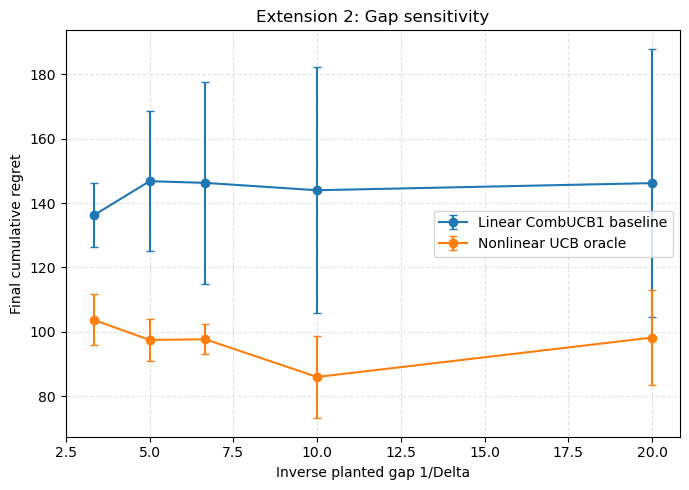

Saved to: extension2_outputs/extension2_gap_sensitivity.png


{'deltas': [0.05, 0.1, 0.15, 0.2, 0.3],
 'inverse_gaps': [20.0, 10.0, 6.666666666666667, 5.0, 3.3333333333333335],
 'linear_mean': [146.20102456361826,
  143.98257194317725,
  146.26923656260925,
  146.80535929504876,
  136.21349806336],
 'linear_std': [41.74023302342936,
  38.22092109492143,
  31.496619707251543,
  21.703935782176906,
  10.017314793527474],
 'nonlinear_mean': [98.18854237006487,
  85.9569975331461,
  97.64753244418158,
  97.46279769166885,
  103.68239569059527],
 'nonlinear_std': [14.848411768258075,
  12.833612512609877,
  4.640875170956854,
  6.51685572425416,
  7.941556556491675]}

In [11]:
gap_results = gap_sensitivity_experiment()
gap_results

## Experiment 2: Sensitivity to diversity strength

This experiment is specific to Extension 2.

It asks:

> When the non-linear diversity reward becomes more important, does the nonlinear oracle help more than the linear baseline?

In [12]:
def lambda_sensitivity_experiment(
    lambdas=(0.0, 0.25, 0.50, 1.00, 1.50, 2.00),
    num_runs=3,
    horizon=200
):
    linear_means = []
    nonlinear_means = []

    linear_stds = []
    nonlinear_stds = []

    for lam in lambdas:
        linear_final = []
        nonlinear_final = []

        for seed in range(num_runs):
            cfg = make_ext2_config(
                horizon=horizon,
                diversity_lambda=lam,
                lam=lam,
                seed=seed
            )

            p_linear = NonlinearCollegeMatchingProblem(cfg)
            p_nonlinear = NonlinearCollegeMatchingProblem(cfg)

            linear_regret = run_algorithm(
                p_linear,
                LinearCombUCB1Baseline(p_linear),
                horizon
            )[-1]

            nonlinear_regret = run_algorithm(
                p_nonlinear,
                NonlinearUCBOracle(p_nonlinear),
                horizon
            )[-1]

            linear_final.append(linear_regret)
            nonlinear_final.append(nonlinear_regret)

        linear_means.append(np.mean(linear_final))
        nonlinear_means.append(np.mean(nonlinear_final))

        linear_stds.append(np.std(linear_final))
        nonlinear_stds.append(np.std(nonlinear_final))

    plt.figure(figsize=(7, 5))

    plt.errorbar(
        lambdas,
        linear_means,
        yerr=linear_stds,
        marker="o",
        capsize=3,
        label="Linear CombUCB1 baseline"
    )

    plt.errorbar(
        lambdas,
        nonlinear_means,
        yerr=nonlinear_stds,
        marker="o",
        capsize=3,
        label="Nonlinear UCB oracle"
    )

    plt.xlabel("Diversity strength lambda")
    plt.ylabel("Final cumulative regret")
    plt.title("Extension 2: Sensitivity to nonlinear diversity reward")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()

    save_path = os.path.join(EXT2_OUTPUT_DIR, "extension2_lambda_sensitivity.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved to:", save_path)

    return {
        "lambdas": list(lambdas),
        "linear_mean": linear_means,
        "linear_std": linear_stds,
        "nonlinear_mean": nonlinear_means,
        "nonlinear_std": nonlinear_stds,
    }

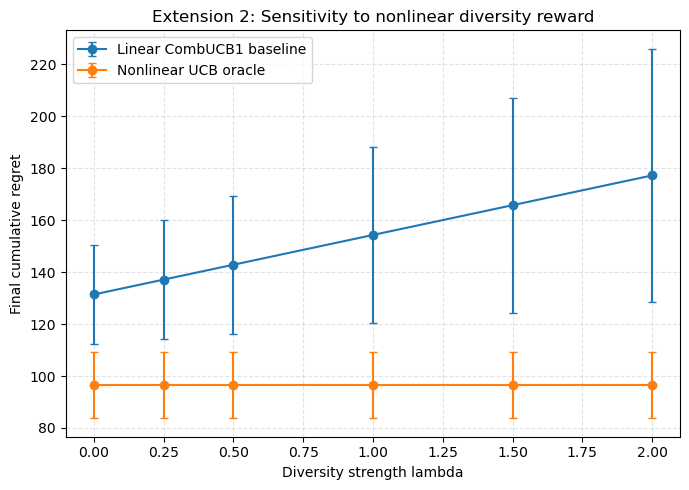

Saved to: extension2_outputs/extension2_lambda_sensitivity.png


{'lambdas': [0.0, 0.25, 0.5, 1.0, 1.5, 2.0],
 'linear_mean': [131.36779437408288,
  137.09416585542294,
  142.8205373367632,
  154.27328029944383,
  165.72602326212396,
  177.17876622480443],
 'linear_std': [19.130217445399335,
  22.82846674300415,
  26.527532380634455,
  33.92704456723095,
  41.32757379876098,
  48.72865669481466],
 'nonlinear_mean': [96.54906815187847,
  96.54906815187842,
  96.54906815187849,
  96.54906815187854,
  96.54906815187833,
  96.54906815187853],
 'nonlinear_std': [12.80605253088387,
  12.806052530883862,
  12.806052530883873,
  12.806052530883923,
  12.80605253088394,
  12.806052530883827]}

In [13]:
lambda_results = lambda_sensitivity_experiment()
lambda_results

## Experiment 3: Ablation study

This ablation compares:

1. linear baseline;
2. nonlinear oracle with diversity only;
3. nonlinear oracle with quadratic interaction only;
4. full nonlinear oracle.

This helps justify why the Extension 2 reward has two non-linear components.

In [14]:
def ablation_experiment(
    num_runs=3,
    horizon=200
):
    settings = [
        {
            "name": "Linear baseline",
            "algo": "linear",
            "diversity_lambda": 0.0,
            "quadratic_gamma": 0.0,
            "lam": 0.0,
            "gamma": 0.0,
        },
        {
            "name": "Diversity only",
            "algo": "nonlinear",
            "diversity_lambda": 1.0,
            "quadratic_gamma": 0.0,
            "lam": 1.0,
            "gamma": 0.0,
        },
        {
            "name": "Quadratic only",
            "algo": "nonlinear",
            "diversity_lambda": 0.0,
            "quadratic_gamma": 1.0,
            "lam": 0.0,
            "gamma": 1.0,
        },
        {
            "name": "Full nonlinear",
            "algo": "nonlinear",
            "diversity_lambda": 1.0,
            "quadratic_gamma": 1.0,
            "lam": 1.0,
            "gamma": 1.0,
        },
    ]

    means = []
    stds = []
    labels = []

    for setting in settings:
        final_regrets = []

        for seed in range(num_runs):
            cfg = make_ext2_config(
                horizon=horizon,
                diversity_lambda=setting["diversity_lambda"],
                quadratic_gamma=setting["quadratic_gamma"],
                lam=setting["lam"],
                gamma=setting["gamma"],
                seed=seed
            )

            problem = NonlinearCollegeMatchingProblem(cfg)

            if setting["algo"] == "linear":
                algo = LinearCombUCB1Baseline(problem)
            else:
                algo = NonlinearUCBOracle(problem)

            regret = run_algorithm(problem, algo, horizon)[-1]
            final_regrets.append(regret)

        labels.append(setting["name"])
        means.append(np.mean(final_regrets))
        stds.append(np.std(final_regrets))

    x = np.arange(len(labels))

    plt.figure(figsize=(8, 5))

    plt.bar(
        x,
        means,
        yerr=stds,
        capsize=4
    )

    plt.xticks(x, labels, rotation=15, ha="right")
    plt.ylabel("Final cumulative regret")
    plt.title("Extension 2: Ablation of nonlinear components")
    plt.grid(axis="y", linestyle="--", alpha=0.35)
    plt.tight_layout()

    save_path = os.path.join(EXT2_OUTPUT_DIR, "extension2_ablation.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved to:", save_path)

    return {
        "labels": labels,
        "mean": means,
        "std": stds,
    }

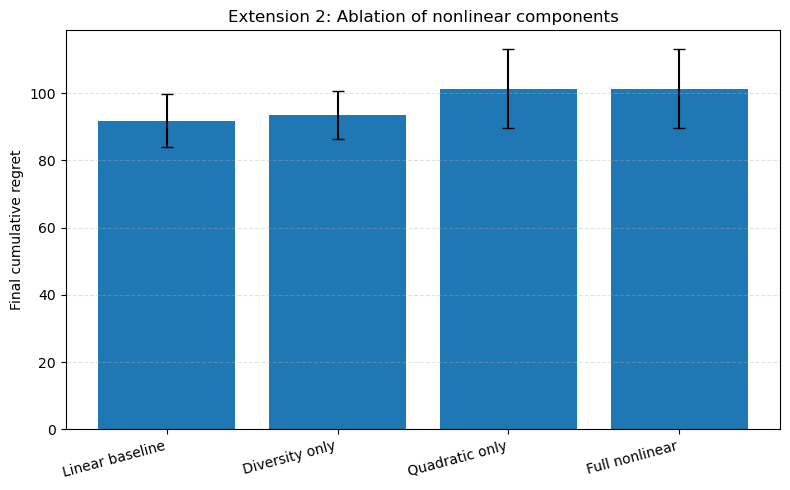

Saved to: extension2_outputs/extension2_ablation.png


{'labels': ['Linear baseline',
  'Diversity only',
  'Quadratic only',
  'Full nonlinear'],
 'mean': [91.84831645042665,
  93.48856335978833,
  101.33829941056838,
  101.33829941056831],
 'std': [7.947823753775573,
  7.02293758812402,
  11.715250224968102,
  11.715250224968088]}

In [15]:
ablation_results = ablation_experiment()
ablation_results

## Experiment 4: Oracle runtime comparison

The linear baseline uses a Hungarian-style oracle, while the nonlinear extension uses an exact oracle by enumerating feasible matchings.

This experiment measures the average selection time.

Important interpretation:

- the exact nonlinear oracle is fine for small synthetic experiments;
- for larger instances, the report should discuss greedy or local-search approximations.

Note: the default runtime experiment uses small sizes `(3, 4, 5)` because the exact nonlinear oracle enumerates feasible matchings and grows quickly.

In [16]:
def oracle_runtime_experiment(
    student_sizes=(3, 4, 5),
    repeats=10
):
    linear_times = []
    nonlinear_times = []
    feasible_counts = []

    for n in student_sizes:
        cfg = make_ext2_config(
            n_students=n,
            n_colleges=n,
            capacities=tuple([n] * n),
            horizon=50,
            seed=0
        )

        problem_linear = NonlinearCollegeMatchingProblem(cfg)
        problem_nonlinear = NonlinearCollegeMatchingProblem(cfg)

        linear_algo = LinearCombUCB1Baseline(problem_linear)
        nonlinear_algo = NonlinearUCBOracle(problem_nonlinear)

        # Warm-up.
        _ = linear_algo.select(1)
        _ = nonlinear_algo.select(1)

        start = time.perf_counter()
        for t in range(1, repeats + 1):
            _ = linear_algo.select(t)
        linear_avg = (time.perf_counter() - start) / repeats

        start = time.perf_counter()
        for t in range(1, repeats + 1):
            _ = nonlinear_algo.select(t)
        nonlinear_avg = (time.perf_counter() - start) / repeats

        linear_times.append(linear_avg)
        nonlinear_times.append(nonlinear_avg)

        if hasattr(nonlinear_algo, "exact_oracle") and hasattr(nonlinear_algo.exact_oracle, "all_matchings"):
            feasible_counts.append(len(nonlinear_algo.exact_oracle.all_matchings))
        else:
            feasible_counts.append(None)

    plt.figure(figsize=(7, 5))

    plt.plot(
        student_sizes,
        linear_times,
        marker="o",
        label="Linear Hungarian oracle"
    )

    plt.plot(
        student_sizes,
        nonlinear_times,
        marker="o",
        label="Exact nonlinear oracle"
    )

    plt.xlabel("Number of students / colleges")
    plt.ylabel("Average selection time seconds")
    plt.title("Extension 2: Oracle runtime comparison")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()

    save_path = os.path.join(EXT2_OUTPUT_DIR, "extension2_oracle_runtime.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    print("Saved to:", save_path)

    for n, count in zip(student_sizes, feasible_counts):
        print(f"n={n}, feasible matchings enumerated={count}")

    return {
        "student_sizes": list(student_sizes),
        "linear_times": linear_times,
        "nonlinear_times": nonlinear_times,
        "feasible_counts": feasible_counts,
    }

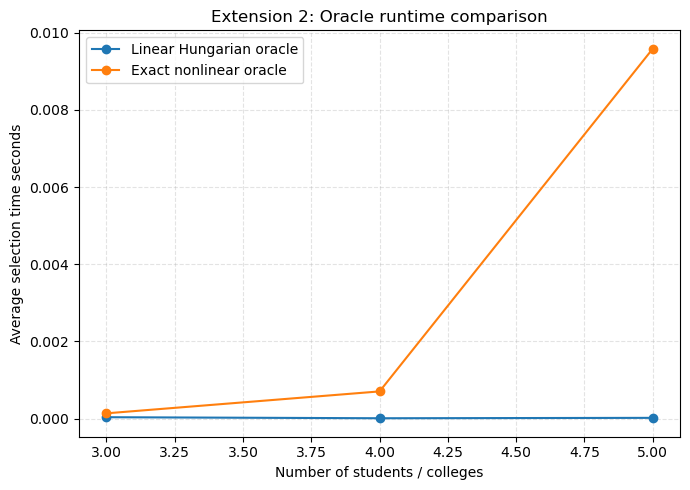

Saved to: extension2_outputs/extension2_oracle_runtime.png
n=3, feasible matchings enumerated=27
n=4, feasible matchings enumerated=256
n=5, feasible matchings enumerated=3125


{'student_sizes': [3, 4, 5],
 'linear_times': [3.6995904520154e-05,
  1.0125013068318367e-05,
  2.03415984287858e-05],
 'nonlinear_times': [0.0001376583008095622,
  0.0007056999951601028,
  0.009584404202178121],
 'feasible_counts': [27, 256, 3125]}

In [17]:
runtime_results = oracle_runtime_experiment()
runtime_results

## Save additional experiment tables

This cell stores all additional experiment results in a text file.

In [18]:
extra_summary_path = os.path.join(EXT2_OUTPUT_DIR, "extension2_additional_experiment_summary.txt")

with open(extra_summary_path, "w") as f:
    f.write("Extension 2 additional experiments\n")
    f.write("=" * 60 + "\n\n")

    f.write("Gap sensitivity\n")
    f.write(str(gap_results) + "\n\n")

    f.write("Lambda sensitivity\n")
    f.write(str(lambda_results) + "\n\n")

    f.write("Ablation\n")
    f.write(str(ablation_results) + "\n\n")

    f.write("Oracle runtime\n")
    f.write(str(runtime_results) + "\n\n")

print("Saved additional experiment summary to:", extra_summary_path)

Saved additional experiment summary to: extension2_outputs/extension2_additional_experiment_summary.txt
